In [2]:
import numpy as np
import matplotlib.pyplot as plt

The frequency response $C_k$ is given by

$$
C_k = \sum_{s=0}^{\tau-1} e^{-2\pi i\, k s / N}
    = e^{-\pi i\, k (\tau-1)/N}\; \frac{\sin(\pi k\tau/N)}{\sin(\pi k/N)}.
$$

The magnitude is
$$
|C_k| = \left|\frac{\sin(\pi k\tau/N)}{\sin(\pi k/N)}\right|.
$$

In [3]:
def compute_Ck(N, tau):
    k = np.arange(N, dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        num = np.sin(np.pi * k * tau / N)
        den = np.sin(np.pi * k / N)
        ratio = np.where(np.abs(den) < 1e-12, tau, num / den)

    phase = np.exp(-1j * np.pi * k * (tau - 1) / N)

    ratio[0] = tau
    phase[0] = 1.0

    return phase * ratio

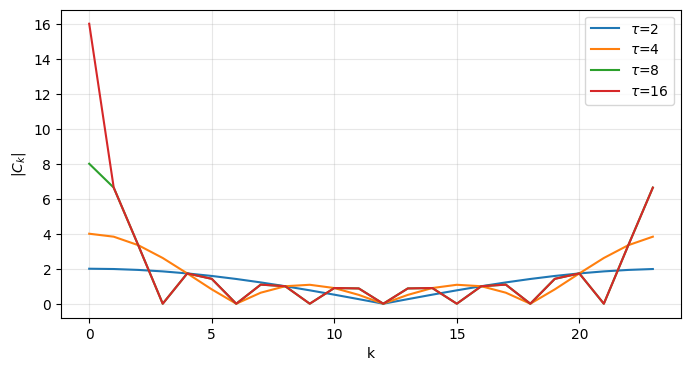

In [21]:
#| label: C_k
N = 24
taus = [2, 4, 8, 16]

k = np.arange(N)

plt.figure(figsize=(8, 4))

for tau in taus:
    Ck = compute_Ck(N, tau)
    plt.plot(k, np.abs(Ck), label=fr"$\tau$={tau}")

plt.xlabel("k")
plt.ylabel(r"$|C_k|$")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Aliasing structure**
$$
A = \begin{cases}
B, & k'\equiv k\pmod{B},\\[2pt]
0, & \text{otherwise}.
\end{cases}
$$

In [7]:
def build_A(N, tau):
    B = N // tau
    k  = np.arange(N)
    kp = np.arange(N)

    return ((kp[None, :] - k[:, None]) % B == 0).astype(float)

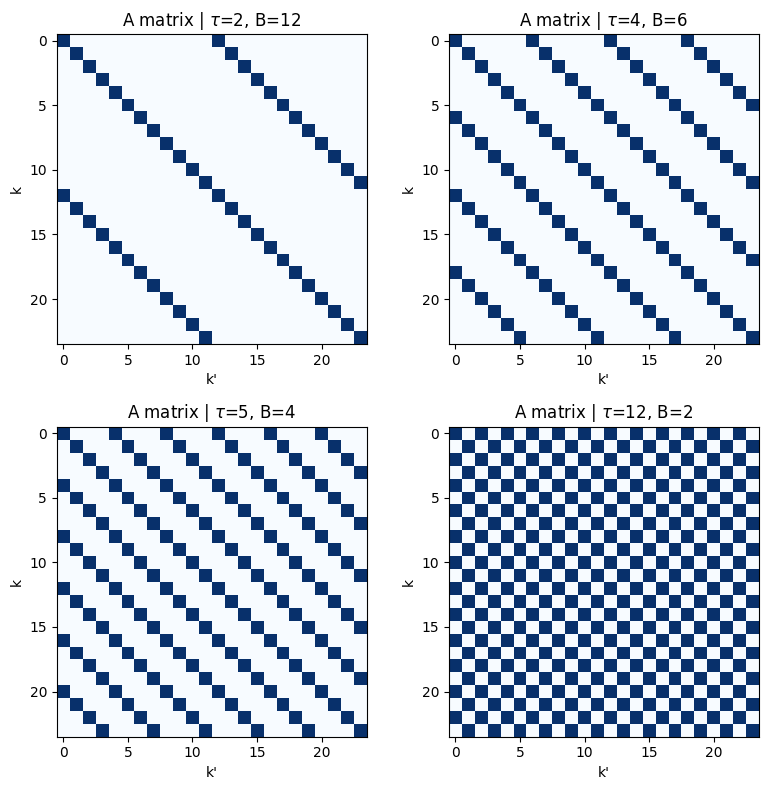

In [20]:
#| label: A_matrix
N = 24
taus = [2, 4, 5, 12]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, tau in enumerate(taus):
    A = build_A(N, tau)
    B = N // tau

    im = axes[i].imshow(A, cmap="Blues", vmin=0, vmax=1)

    axes[i].set_title(fr"A matrix | $\tau$={tau}, B={B}")
    axes[i].set_xlabel("k'")
    axes[i].set_ylabel("k")

plt.tight_layout()
plt.show()

$$
(\mathbf{F}\mathbf{J}\mathbf{F}^{\dagger})_{kk'} = \frac{B}{N}\,C_k C_{k'}^* = \frac{C_k C_{k'}^*}{\tau}.
$$

In [14]:
def build_FJFdagger(N, tau):
    Ck = compute_Ck(N, tau)
    A  = build_A(N, tau)

    outer = np.outer(Ck, np.conj(Ck)) / tau

    return outer * A

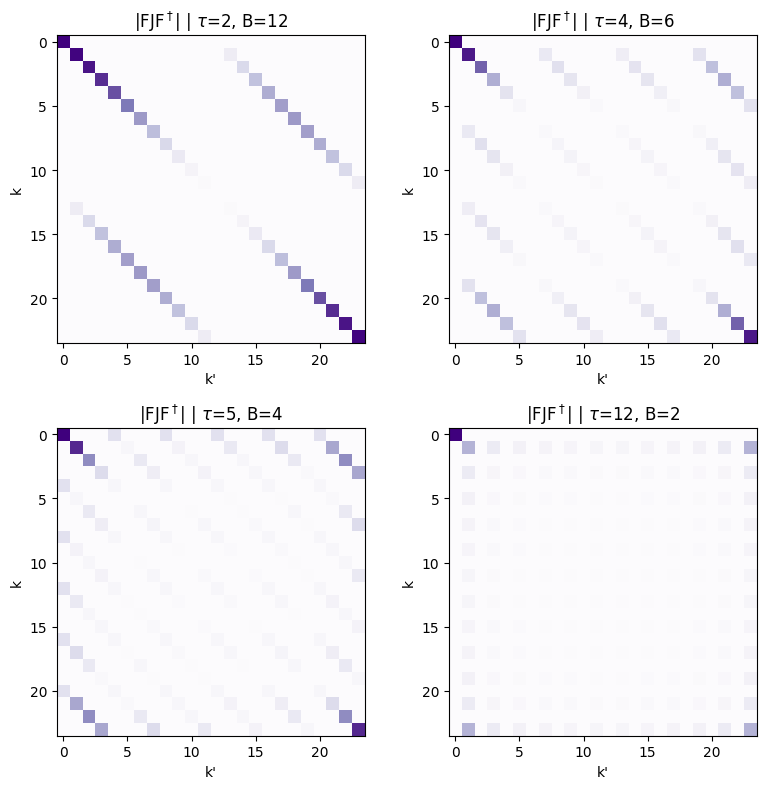

In [22]:
#| label: FJF_dagger
N = 24
taus = [2, 4, 5, 12]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, tau in enumerate(taus):
    FJFd = build_FJFdagger(N, tau)
    B = N // tau

    im = axes[i].imshow(np.abs(FJFd), cmap="Purples")

    axes[i].set_title(fr"$\rm |F J F^\dagger|$ | $\tau$={tau}, B={B}")
    axes[i].set_xlabel("k'")
    axes[i].set_ylabel("k")

plt.tight_layout()
plt.show()

$$
(\tilde{\mathbf{D}}_{\rm T})_{kk'} = \delta_{kk'} - \frac{1}{\tau}\,(\mathbf{F}\mathbf{J}\mathbf{F}^{\dagger})_{kk'}.
$$

In [15]:
def build_DT_fourier(N, tau):
    FJFd = build_FJFdagger(N, tau)
    return np.eye(N) - FJFd / tau

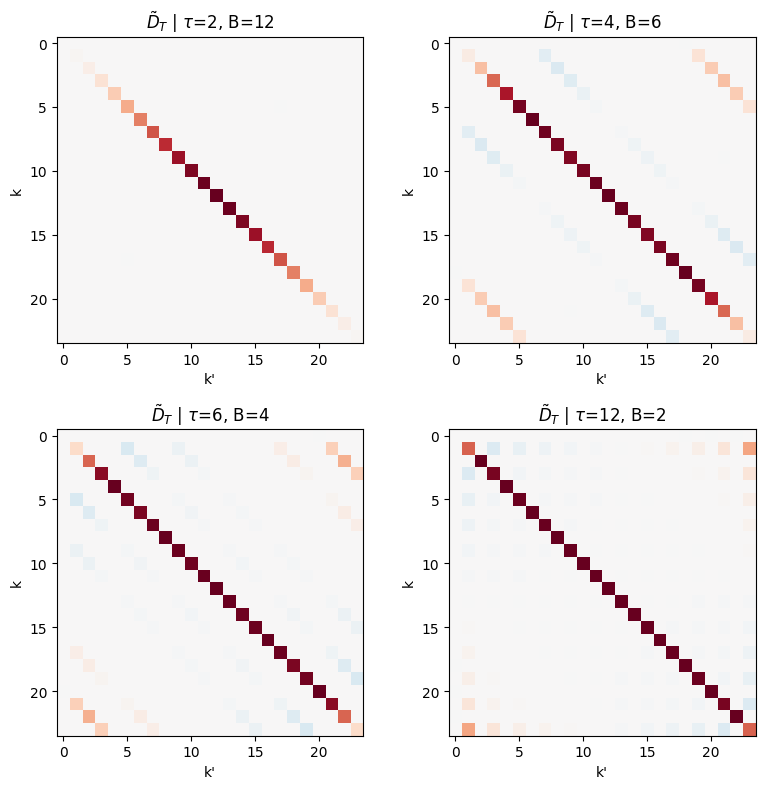

In [25]:
#| label: D_T_fourier
N = 24
taus = [2, 4, 6, 12]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

# consistent color scale
all_DT = [np.real(build_DT_fourier(N, tau)) for tau in taus]
vmax = max(np.max(np.abs(DT)) for DT in all_DT)

for i, tau in enumerate(taus):
    DT = all_DT[i]
    B = N // tau

    im = axes[i].imshow(DT, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(fr"$\tilde D_T$ | $\tau$={tau}, B={B}")
    axes[i].set_xlabel("k'")
    axes[i].set_ylabel("k")

plt.tight_layout()
plt.show()